# Módulo 2 · Modelos fundacionales de series temporales
## Notebook 3 — **Chronos** y **TimesFM** (predicción *zero-shot*)


---
## 0. Preparación del entorno
La primera ejecución **descarga los pesos** desde HuggingFace (decenas–cientos de
MB). En Colab, un *runtime* con **GPU** acelera bastante TimesFM (en CPU también
funciona, solo más lento). Chronos-Bolt es pequeño y va rápido en CPU.

In [ ]:
# @title Setup (ejecutar primero) { display-mode: "form" }
import sys, subprocess
def _pip(pkgs):
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *pkgs], check=False)
_pip(["yfinance", "chronos-forecasting", "timesfm"])

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
plt.rcParams["figure.figsize"] = (12, 4.5)
RANDOM_STATE = 42
print(f"Entorno listo ✅  dispositivo: {DEVICE}")

Entorno listo ✅  dispositivo: cpu


---
## 1. Los datos
Mismos precios del S&P 500 (con *fallback* sintético). A diferencia del LSTM, aquí
**no** convertimos a rendimientos ni escalamos: los modelos fundacionales hacen su
propia normalización interna y predicen el **nivel** directamente.

Planteamos la tarea más natural para ellos: damos todo el histórico **menos los
últimos `H` días** como *contexto* y les pedimos que pronostiquen esos `H` días.

In [ ]:
TICKER = "^GSPC"
START, END = "2015-01-01", "2024-12-31"

def load_prices():
    try:
        import yfinance as yf
        data = yf.download(TICKER, start=START, end=END, progress=False, auto_adjust=True)
        if data is None or len(data) == 0:
            raise RuntimeError("descarga vacía")
        s = data["Close"]; s = s.iloc[:, 0] if isinstance(s, pd.DataFrame) else s
        print(f"Datos reales: {len(s)} sesiones de {TICKER}")
        return s.rename("Close")
    except Exception as e:
        print(f"⚠️  Sin datos reales ({e}). Serie SINTÉTICA con hechos estilizados.")
        rng = np.random.default_rng(RANDOM_STATE); n = 2400; base = np.log(0.009)
        logvol = np.full(n, base)
        for t in range(1, n):
            logvol[t] = 0.94*logvol[t-1] + 0.06*base + 0.15*rng.standard_normal()
        sigma = np.exp(logvol); z = rng.standard_t(df=10, size=n)/np.sqrt(10/8.0)
        ret = 0.0007 + sigma*z; jumps = rng.random(n) < 0.012
        ret[jumps] -= np.abs(rng.normal(0.0, 0.03, jumps.sum())); ret[850:910] -= 0.012
        idx = pd.bdate_range("2015-01-02", periods=n)
        return pd.Series(2000*np.exp(np.cumsum(ret)), index=idx, name="Close")

prices = load_prices()

H = 60                                       # horizonte: 60 días hábiles (~3 meses)
series  = prices.values.astype("float32")
context = series[:-H]                        # lo que ven los modelos
actual  = series[-H:]                        # lo que NO ven (para evaluar)
ctx_dates, fut_dates = prices.index[:-H], prices.index[-H:]
print(f"Contexto: {len(context)} días  |  Horizonte a predecir: {H} días")

Datos reales: 2515 sesiones de ^GSPC
Contexto: 2455 días  |  Horizonte a predecir: 60 días


---
## 2 · ¿Qué es un modelo fundacional de series temporales?

La analogía con los LLM es casi literal:

| | LLM (texto) | TSFM (series temporales) |
|---|---|---|
| Pre-entrenado con | billones de palabras | millones de series |
| Lo que aprende | "gramática" del lenguaje | "gramática" de las series (tendencia, estacionalidad, picos…) |
| Uso | *prompt* → respuesta | *contexto* → pronóstico |
| Sin entrenar en tu caso | responde igual (*zero-shot*) | pronostica igual (*zero-shot*) |

**Cómo funcionan (intuición).** Convierten la serie en una secuencia de *tokens*
(Chronos cuantiza valores; TimesFM usa *patches*) y un transformer predice los
siguientes — igual que un LLM predice la próxima palabra. Salen **pronósticos
probabilísticos**: no un número, sino **cuantiles** (p. ej. percentiles 10/50/90),
es decir, una banda de incertidumbre.


---
## 3. Chronos (Amazon) — *zero-shot*
Usamos `chronos-bolt-small`: rápido y va bien en CPU. El patrón es de tres líneas:
cargar, predecir cuantiles, dibujar. Completa el `# TODO` de la llamada.

In [ ]:
from chronos import BaseChronosPipeline

chronos = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map=DEVICE,
    torch_dtype=torch.float32,
)

# TODO: pide cuantiles 10/50/90 para los próximos H días.
#   - 1er argumento (posicional): el contexto como tensor -> torch.tensor(context)
#   - prediction_length=H
#   - quantile_levels=[0.1, 0.5, 0.9]
q_chronos, _ = chronos.predict_quantiles(
    torch.tensor(context),       # contexto como tensor de PyTorch
    prediction_length=H,         # 60 días a predecir
    quantile_levels=[0.1, 0.5, 0.9],  # percentiles 10, 50 y 90
)
# q_chronos: tensor [1, H, 3]  ->  columnas = (p10, p50, p90)
q_chronos = q_chronos[0].detach().cpu().numpy()
lo_c, med_c, hi_c = q_chronos[:, 0], q_chronos[:, 1], q_chronos[:, 2]
print("Forma de los cuantiles:", q_chronos.shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/191M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

Forma de los cuantiles: (60, 3)


In [ ]:
#@title 💡 Solución — llamada a Chronos
from chronos import BaseChronosPipeline

chronos = BaseChronosPipeline.from_pretrained(
    "amazon/chronos-bolt-small",
    device_map=DEVICE,
    torch_dtype=torch.float32,
)

q_chronos, _ = chronos.predict_quantiles(
    torch.tensor(context),
    prediction_length=H,
    quantile_levels=[0.1, 0.5, 0.9],
)
q_chronos = q_chronos[0].detach().cpu().numpy()
lo_c, med_c, hi_c = q_chronos[:, 0], q_chronos[:, 1], q_chronos[:, 2]
print("✅ cuantiles:", q_chronos.shape)

Loading weights:   0%|          | 0/143 [00:00<?, ?it/s]

✅ cuantiles: (60, 3)


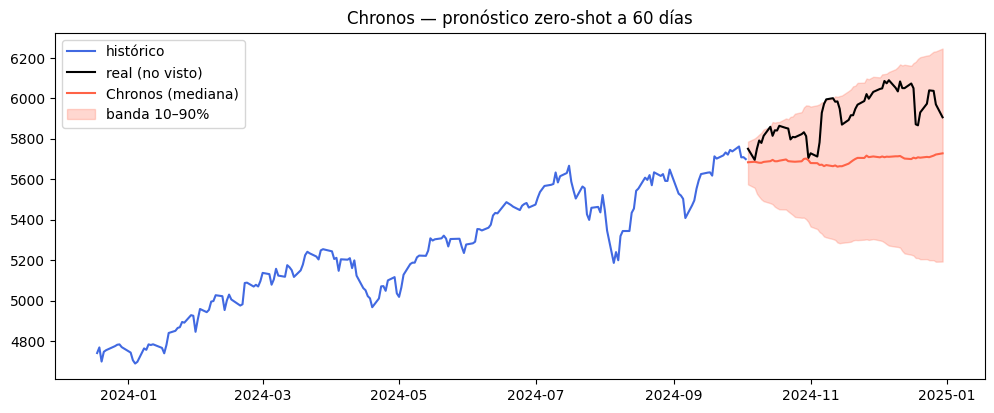

In [ ]:
# Dibujamos: últimos 200 días de histórico + pronóstico con banda 10–90%
hist_n = 200
plt.plot(ctx_dates[-hist_n:], context[-hist_n:], color="royalblue", label="histórico")
plt.plot(fut_dates, actual, color="black", lw=1.5, label="real (no visto)")
plt.plot(fut_dates, med_c, color="tomato", label="Chronos (mediana)")
plt.fill_between(fut_dates, lo_c, hi_c, color="tomato", alpha=0.25, label="banda 10–90%")
plt.title("Chronos — pronóstico zero-shot a 60 días"); plt.legend(); plt.show()

---
## 4. TimesFM (Google) — *zero-shot*
API distinta (cambió en la versión 2.5): se carga, se "compila" con una
`ForecastConfig` y se llama a `forecast`. Devuelve la media y **10 cuantiles**
(media + percentiles 10…90).

In [ ]:
import timesfm

tfm = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
tfm.compile(
    timesfm.ForecastConfig(
        max_context=1024,
        max_horizon=128,
        normalize_inputs=True,
        use_continuous_quantile_head=True,
        fix_quantile_crossing=True,
    )
)

# forecast(horizon, inputs=[serie]) -> (point[n,H], quantiles[n,H,10])
point_tfm, q_tfm = tfm.forecast(horizon=H, inputs=[context])
# q_tfm[0]: [H, 10] -> col 0 = media; cols 1..9 = percentiles 10..90
q0 = q_tfm[0]
med_t, lo_t, hi_t = q0[:, 5], q0[:, 1], q0[:, 9]   # p50, p10, p90
print("point:", point_tfm.shape, "| quantiles:", q_tfm.shape)

config.json:   0%|          | 0.00/475 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/925M [00:00<?, ?B/s]

point: (1, 60) | quantiles: (1, 60, 10)


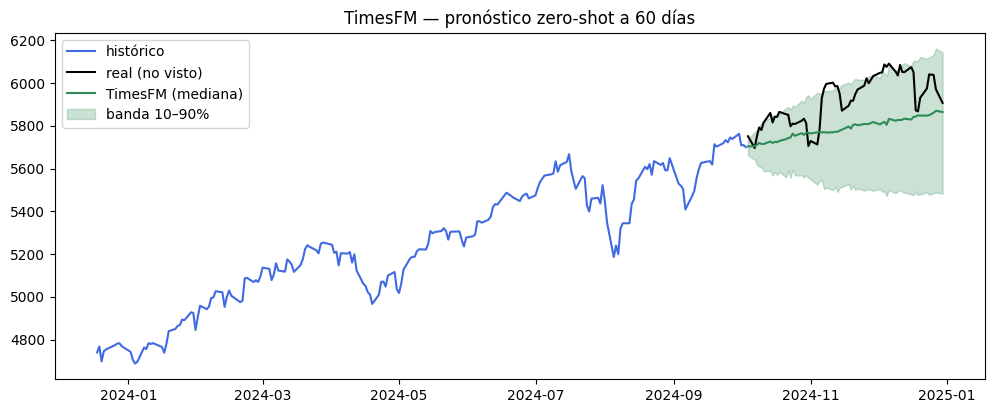

In [ ]:
plt.plot(ctx_dates[-hist_n:], context[-hist_n:], color="royalblue", label="histórico")
plt.plot(fut_dates, actual, color="black", lw=1.5, label="real (no visto)")
plt.plot(fut_dates, med_t, color="seagreen", label="TimesFM (mediana)")
plt.fill_between(fut_dates, lo_t, hi_t, color="seagreen", alpha=0.25, label="banda 10–90%")
plt.title("TimesFM — pronóstico zero-shot a 60 días"); plt.legend(); plt.show()

---
## 6. Síntesis del módulo: los cinco paradigmas

| | ARIMA | XGBoost | LSTM | **Chronos / TimesFM** |
|---|---|---|---|---|
| Paradigma | clásico | ML | DL | **fundacional** |
| Entrena en tu serie | sí | sí | sí | **no (zero-shot)** |
| Feature engineering | — | **tú** | la red | ninguno |
| Datos propios necesarios | pocos | medios | muchos | **ninguno para empezar** |
| Salida | puntual + IC | puntual | puntual | **probabilística nativa** |
| Coste | ínfimo | bajo | medio-alto | **modelo grande, pero sin entrenar** |
| Interpretable | sí | media | no | no |
